In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
DB_PATH = "../data/telegram.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)
tables = con.execute("SHOW TABLES").fetchdf()
tables

,name
0,telegram


In [5]:
if tables.empty:
    raise ValueError("No tables found in DuckDB database.")

table_name = tables["name"].iloc[0]
df = con.execute(f'SELECT * FROM "{table_name}"').fetchdf()
df.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,id,dt_published,translated_content,channel_name,channel_id
0,7834776,2025-09-03 06:35:42,Alert from the Home Front Command (preliminary...,aaa123441,1669756453
1,7834775,2025-09-03 06:39:41,Alert from the Home Front Command • Dan: Tel A...,aaa123441,1669756453
2,7834774,2025-09-03 06:49:44,Message from the Home Front Command (Event Con...,aaa123441,1669756453
3,7834773,2025-09-03 06:49:46,Message from the Home Front Command (Event Con...,aaa123441,1669756453
4,7834772,2025-09-03 06:50:33,Message from the Home Front Command (Event Con...,aaa123441,1669756453


In [6]:
df["dt_published"] = pd.to_datetime(df["dt_published"], errors="coerce")
df = df.dropna(subset=["dt_published"])

In [7]:
def count_by_frequency(data: pd.DataFrame, freq: str) -> pd.Series:
    """Count messages by time frequency.

    Args:
        data: Input dataframe with a dt_published column.
        freq: Pandas offset alias like "D", "W", or "M".

    Returns:
        Series indexed by period start with message counts.
    """
    counts = (
        data.set_index("dt_published")
        .resample(freq)
        .size()
        .rename("message_count")
    )
    return counts

/tmp/ipykernel_198988/3108047455.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample(freq)


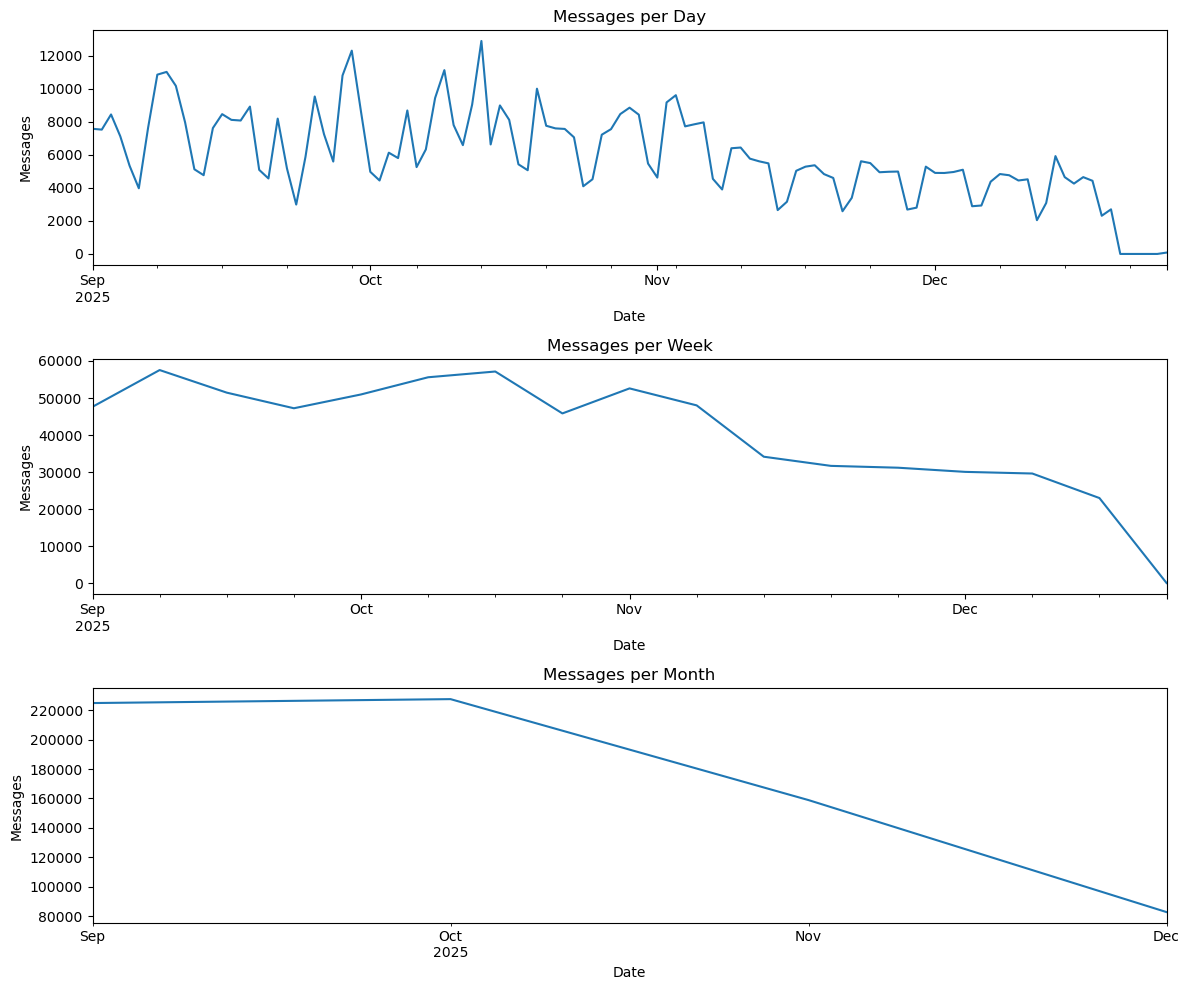

In [8]:
counts_day = count_by_frequency(df, "D")
counts_week = count_by_frequency(df, "W")
counts_month = count_by_frequency(df, "M")

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=False)
counts_day.plot(ax=axes[0], title="Messages per Day")
counts_week.plot(ax=axes[1], title="Messages per Week")
counts_month.plot(ax=axes[2], title="Messages per Month")
for ax in axes:
    ax.set_xlabel("Date")
    ax.set_ylabel("Messages")
fig.tight_layout()

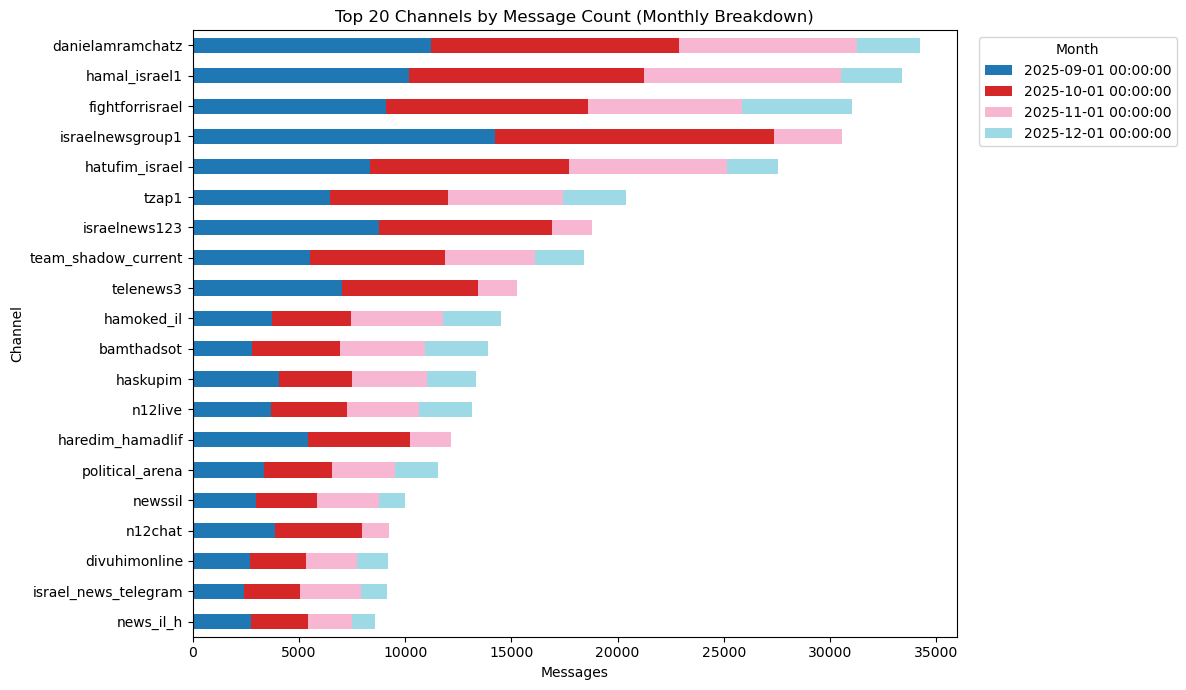

In [9]:
# Top 20 Channels by Message Count (stacked by month)
df_month = df.copy()
df_month['channel_name_clean'] = df_month['channel_name'].fillna('Unknown')
df_month['month'] = df_month['dt_published'].dt.to_period('M').dt.to_timestamp()
top_channels = df_month['channel_name_clean'].value_counts().head(20).index
df_month = df_month[df_month['channel_name_clean'].isin(top_channels)]
monthly_counts = (
    df_month.groupby(['channel_name_clean', 'month'])
    .size()
    .unstack(fill_value=0)
)
monthly_counts = monthly_counts.loc[monthly_counts.sum(axis=1).sort_values().index]
ax = monthly_counts.plot(kind='barh', stacked=True, colormap='tab20', figsize=(12, 7))
ax.set_title('Top 20 Channels by Message Count (Monthly Breakdown)')
ax.set_xlabel('Messages')
ax.set_ylabel('Channel')
ax.legend(title='Month', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
